# Stochastic Hydrology - Semester project 
## Group 26 Alisa Tarnovskaya, Javier Feller

## 1. Data loading 

In [112]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from scipy.stats import genextreme as gev
import numpy as np
import pymannkendall as mk


### 1.1 Inspect hydrological and attribut data

In [2]:
hydro_df=pd.read_csv(r"..\data\static_attributes\CAMELS_CH_hydrology_attributes_obs.csv", skiprows=1)
attributes_df=pd.read_csv(r"C:\Users\Javier Feller\Documents\UZH\Master\FS26\Stochastic Hydrology\Project\Git_stochastic_hydrology\data\static_attributes\CAMELS_CH_topographic_attributes.csv", encoding="cp1252", skiprows=1)
hydro_df.columns
hydro_df.head(10)
attributes_df

,gauge_id,country,gauge_name,water_body_name,id6,water_body_type,gauge_lon,gauge_lat,gauge_easting,gauge_northing,...,elev_min,elev_percentile10,elev_percentile25,elev_percentile50,elev_percentile75,elev_percentile90,elev_max,slope_mean,flat_area_perc,steep_area_perc
0,2004,CH,Murten,Murtensee,MuSMur,lake,7.12,46.93,2575500,1197790,...,428.75,444.02,501.91,645.40,747.73,835.77,1499.39,5.53,38.15,5.23
1,2007,CH,Le_Pont,Lac_de_Joux,LdJLeP,lake,6.32,46.67,2514700,1168840,...,999.58,1043.15,1112.37,1235.46,1328.30,1400.98,1660.32,8.13,21.39,12.76
2,2009,CH,Porte_du_Scex,Rhône,RhoPor,stream,6.89,46.35,2557660,1133280,...,377.07,1015.99,1560.86,2191.36,2698.04,3103.99,4521.34,25.72,3.62,79.60
3,2011,CH,Sion,Rhône,RhoSio,stream,7.36,46.22,2593770,1118630,...,485.83,1209.13,1778.17,2379.66,2821.90,3208.04,4521.34,25.82,2.83,80.15
4,2014,CH,Schmerikon,Zürichsee_(Obersee),ZuSSch,lake,8.94,47.22,2713710,1231515,...,401.92,448.27,753.15,1312.10,1842.57,2202.29,3557.05,22.10,11.86,65.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
326,6007,I,Candoglia,Fiume_Toce,TocCan,stream,8.42,45.97,2676202,1091943,...,198.37,639.53,1133.32,1724.32,2222.43,2566.44,4517.33,28.61,4.08,85.14
327,6008,I,Gravellona,Torrente_Strona,StrGra,stream,8.43,45.93,2677233,1086632,...,210.45,292.04,459.97,824.81,1184.37,1591.03,2379.77,21.26,10.89,68.41
328,6009,I,Santino,Torrente_San_Bernardino,SaBSan,stream,8.53,45.96,2684260,1090031,...,236.99,648.57,942.48,1265.41,1573.46,1805.80,2274.60,31.66,0.27,93.60
329,6010,I,Verbania,Torrente_San_Giovanni,SaGVer,stream,8.58,45.94,2688426,1088391,...,191.12,402.41,637.08,922.57,1162.51,1383.42,2117.61,24.84,2.33,80.71


#### 1.2 Overview of all gauging stations in Switzerland

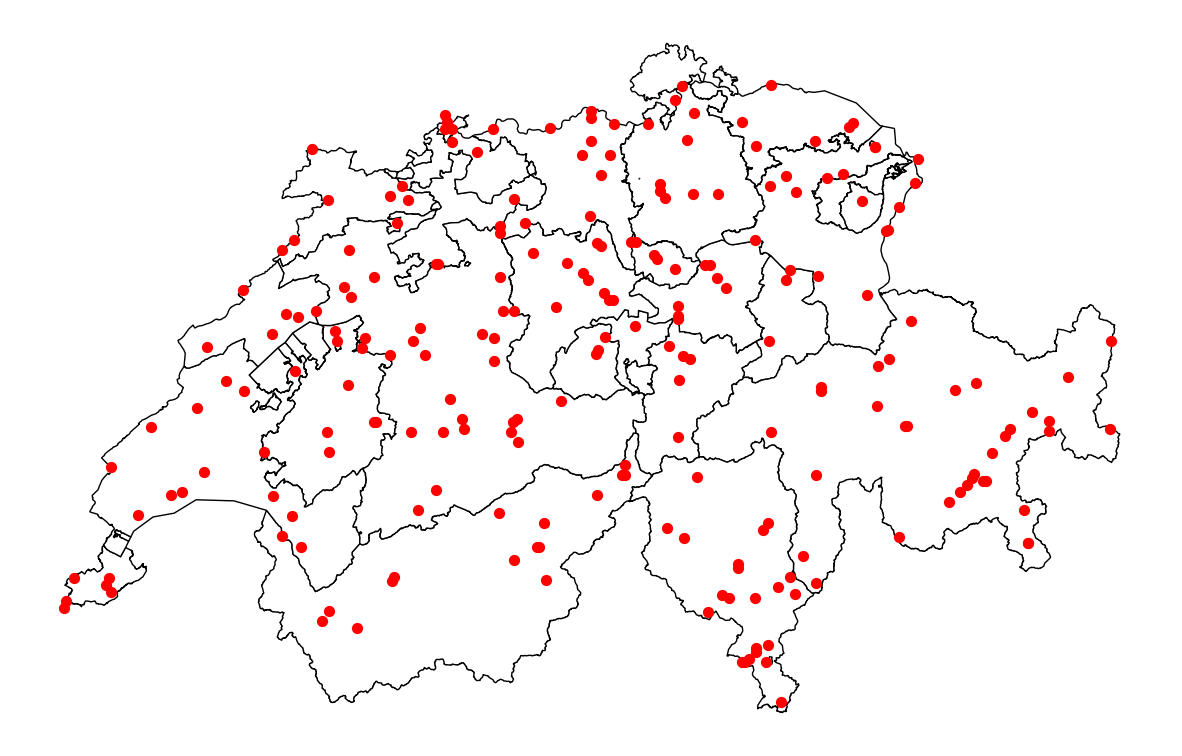

In [49]:
boundaries=gpd.read_file(r"C:\Users\Javier Feller\Documents\UZH\Master\FS26\Stochastic Hydrology\Project\Git_stochastic_hydrology\data\swissboundaries3d_2026-01_2056_5728.gpkg\swissBOUNDARIES3D_1_5_LV95_LN02.gpkg", layer="tlm_kantonsgebiet")
attributes_gdf=gpd.GeoDataFrame(attributes_df, geometry=gpd.points_from_xy(attributes_df["gauge_lon"], attributes_df["gauge_lat"]), crs=4326)
attributes_df=attributes_df[attributes_df["country"]=="CH"]

attributes_gdf=attributes_gdf.to_crs(2056)
boundaries=boundaries.to_crs(2056)
fig, ax = plt.subplots(figsize=(15, 16))


boundaries.plot(ax=ax, color="white", edgecolor="black")

attributes_gdf.plot(ax=ax, color="red", markersize=50)

ax.set_axis_off()
plt.show()

### 1.3 Select gauging stations of watershed Rhone

In [50]:
attributes_df[attributes_df["water_body_name"]=="Rhône"]

,gauge_id,country,gauge_name,water_body_name,id6,water_body_type,gauge_lon,gauge_lat,gauge_easting,gauge_northing,...,elev_min,elev_percentile10,elev_percentile25,elev_percentile50,elev_percentile75,elev_percentile90,elev_max,slope_mean,flat_area_perc,steep_area_perc
2,2009,CH,Porte_du_Scex,Rhône,RhoPor,stream,6.89,46.35,2557660,1133280,...,377.07,1015.99,1560.86,2191.36,2698.04,3103.99,4521.34,25.72,3.62,79.60
3,2011,CH,Sion,Rhône,RhoSio,stream,7.36,46.22,2593770,1118630,...,485.83,1209.13,1778.17,2379.66,2821.90,3208.04,4521.34,25.82,2.83,80.15
13,2024,CH,Branson,Rhône,RhoBra,stream,7.09,46.13,2573150,1108300,...,456.71,1119.07,1704.02,2323.10,2781.24,3171.12,4521.34,25.58,3.27,79.57
85,2174,CH,Chancy-Aux_Ripes,Rhône,RhoCha,stream,5.97,46.15,2486600,1112340,...,335.89,432.54,709.14,1464.81,2302.79,2864.01,4787.66,19.74,16.83,59.30
102,2217,CH,Chancy-Vers_Vaux,Rhône,RhoCVV,stream,5.96,46.13,2485440,1110040,...,329.87,432.08,696.37,1451.19,2293.60,2859.19,4787.66,19.61,17.02,58.85
210,2606,CH,Genève-Halle_de_l'ìle,Rhône,RhoGen,stream,6.14,46.20,2499890,1117850,...,367.12,416.65,749.42,1610.01,2437.17,2932.50,4521.34,20.21,16.95,61.12


In [76]:
hydro_df.columns
sion_gauge=hydro_df[hydro_df["gauge_id"]==2014]
sion_gauge.head(3)

,gauge_id,sign_start_date,sign_end_date,sign_number_of_years,q_mean,runoff_ratio,stream_elas,slope_fdc,baseflow_index_landson,hfd_mean,Q5,Q95,high_q_freq,high_q_dur,low_q_freq,low_q_dur,zero_q_freq
4,2014,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Branson gauging station- Rhone

In [ ]:
branson_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2014.csv")
branson_gauge_annual["date"] = pd.to_datetime(branson_gauge_annual["date"])

branson_gauge_90 = branson_gauge_annual[branson_gauge_annual["date"] > "2010-01-01"]
branson_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
10593,2010-01-02,NaN,NaN,405.861,1.33,-12.41,-8.76,-5.59,1.12,45.0
10594,2010-01-03,NaN,NaN,405.824,0.00,-13.13,-10.05,-6.27,97.03,46.0
10595,2010-01-04,NaN,NaN,405.809,1.17,-11.14,-7.20,-5.24,0.74,46.0


#### Sion gauging station - Rhone

In [87]:
sion_gauge=hydro_df[hydro_df["gauge_id"]==2011]
sion_gauge_annual=pd.read_csv(r"..\data\timeseries\observation_based\CAMELS_CH_obs_based_2011.csv")
sion_gauge_annual["date"] = pd.to_datetime(sion_gauge_annual["date"])

sion_gauge_90 = sion_gauge_annual[sion_gauge_annual["date"] > "1990-01-01"]
sion_gauge_90.head(3)

,date,discharge_vol(m3/s),discharge_spec(mm/d),waterlevel(m),precipitation(mm/d),temperature_min(degC),temperature_mean(degC),temperature_max(degC),rel_sun_dur(%),swe(mm)
3288,1990-01-02,26.587,0.681,483.193,0.0,-10.33,-7.37,-3.37,99.19,NaN
3289,1990-01-03,36.718,0.941,483.359,0.0,-8.93,-6.45,-2.19,99.50,NaN
3290,1990-01-04,44.049,1.129,483.461,0.0,-10.36,-7.43,-2.88,99.74,NaN


#### Sion gauging station - Rhone - Daily discharge frequency diagram 1990-2020

<Axes: title={'center': 'Daily discharge [m3/s] at gauging station of Sion'}, xlabel='Date', ylabel='Discharge [m3/s] '>

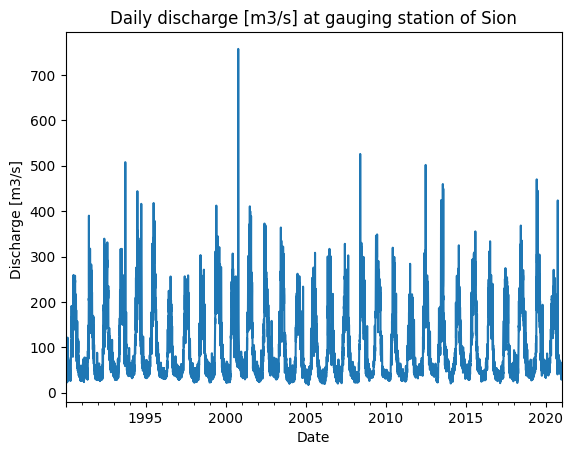

In [98]:
sion_gauge_90["date"] = pd.to_datetime(sion_gauge_90["date"])
sion_gauge_90 = sion_gauge_90.set_index("date", drop=False)

sion_gauge_90["discharge_vol(m3/s)"].plot(title="Daily discharge [m3/s] at gauging station of Sion", xlabel="Date", ylabel="Discharge [m3/s] ")


## 2. Data analysis

## 2.1 Check for stationarity

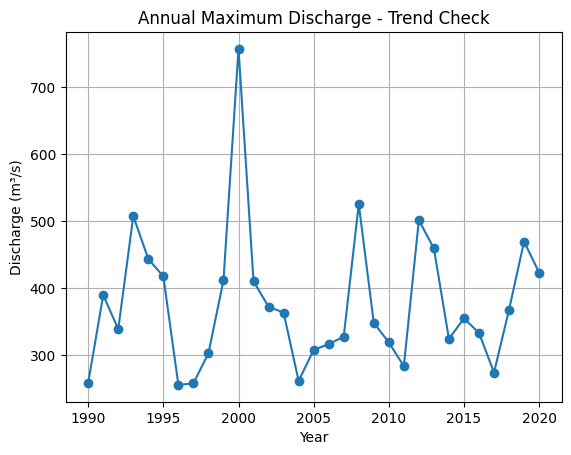

In [109]:
import matplotlib.pyplot as plt

annual_max = annual_max.dropna()

plt.plot(annual_max.index.year, annual_max.values, marker="o")
plt.title("Annual Maximum Discharge - Trend Check")
plt.xlabel("Year")
plt.ylabel("Discharge (m³/s)")
plt.grid(True)
plt.show()

In [113]:
result = mk.original_test(annual_max.values)
print(result)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.6833368087995224), z=np.float64(0.4079140071942694), Tau=np.float64(0.053763440860215055), s=np.float64(25.0), var_s=3461.6666666666665, slope=np.float64(0.7543750000000031), intercept=np.float64(344.0363749999999))


In [119]:
# check for data period (30-50 years are good)
len(annual_max.dropna())

31

### 2.1 Extreme value analysis using return period of 2 or 10 years

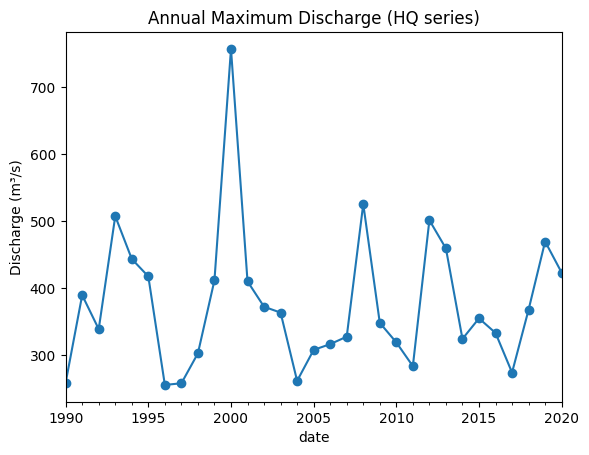

In [120]:
annual_max=sion_gauge_90["discharge_vol(m3/s)"].resample("YE").max()

annual_max.plot(marker="o")
plt.title("Annual Maximum Discharge (HQ series)")
plt.ylabel("Discharge (m³/s)")
plt.show()

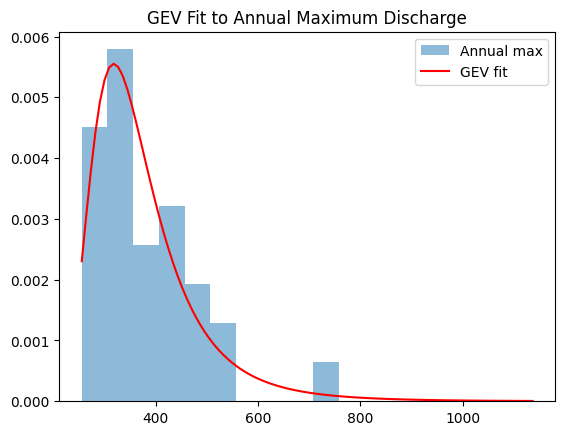

In [121]:
# Fit paramaters of distribution (first drop NA values)
data = annual_max.dropna().values
shape, loc, scale = gev.fit(data)

#compute
x = np.linspace(min(data), max(data)*1.5, 100)

pdf = gev.pdf(x, shape, loc=loc, scale=scale)

# Plot
plt.hist(data, bins=10, density=True, alpha=0.5, label="Annual max")
plt.plot(x, pdf, "r-", label="GEV fit")

plt.legend()
plt.title("GEV Fit to Annual Maximum Discharge")
plt.show()

In [122]:
def return_level(T):
    p = 1 - 1/T
    return gev.ppf(p, shape, loc=loc, scale=scale)

HQ2 = return_level(2)
HQ10 = return_level(10)
HQ100 = return_level(100)

print("HQ2:", HQ2)
print("HQ10:", HQ10)
print("HQ100:", HQ100)

HQ2: 352.898954474473
HQ10: 507.09883663104813
HQ100: 772.1962774671208


In [ ]:
### Purpose

# This document contains R functions to compute streamflow indices (hydrological signatures).
# These functions have been used and are still used to produce the CAMELS datasets. The wrapper
# compute_hydro_signatures_camels enables the computation of the signatures selected for the
# original CAMELS paper (Addor et al., 2017, HESS).

# For some signatures, several formulations have been implemented and the resulting estimates are
# returned as a data.frame. Alternative formulations can be added. The objective is to assess the
# sensitvity of the results to the formulation of the hydrological signatures.

library(here)

### Load functions
source(here::here('utils/time_tools.R')) # For month2sea and get_hydro_year

### Wrapper and parameter values to compute standard camels hydrological signatures

# q_mean         - Mean daily discharge
# runoff_ratio   - Runoff ratio (ratio of mean daily discharge to mean daily precipitation)
# stream_elas    - Streamflow precipitation elasticity (sensitivity of streamflow to changes in
#                  precipitation at the annual time scale)
# slope_fdc      - Slope of the flow duration curve (between 33rd and 66th streamflow percentiles)
# baseflow_index - Baseflow index (ratio of mean daily baseflow to mean daily discharge)
# hfd_mean       - Mean half-flow date (date on which the cumulative discharge since October first
#                  reaches half of the annual discharge)
# Q5             -  5% Flow quantile (low flow)
# Q95            - 95% Flow quantile (high flow)
# high_q_freq    - Frequency of high-flow days (>9 times the median daily flow)
# high_q_dur     - Frequency of high-flow days (>9 times the median daily flow)
# low_q_freq     - Frequency of low-flow days (<0.2 times the mean daily flow)
# low_q_dur      - Average duration of low-flow events (number of consecutive days <0.2 times
#                  the mean daily flow)
# zero_q_freq    - Frequency of days with Q = 0 mm/day

compute_hydro_signatures_camels <- function(q, p, d, tol, hydro_year_cal) {

  # Input variables:
  # q: discharge time series
  # p: precipitation time series
  # d: date array of class "Date"
  # tol: tolerated fraction of NA values in time series
  # hydro_year_cal: hydrological year calendar: oct OR sep OR apr

  qxx <- compute_qXX(q, thres = c(0.05, 0.95), tol)
  hf_stats <- compute_hf_freq_dur(q, d, tol)
  lf_stats <- compute_lf_freq_dur(q, d, tol)
  bfi <- comp_i_bf(q, d, alpha = 0.925, passes = 3, tol)

  data.frame(q_mean = compute_q_mean(q, d, tol)$q_mean_yea,
             runoff_ratio = comp_r_qp(q, p, tol),
             stream_elas = comp_e_qp(q, p, d, tol, hydro_year_cal)$e_qp_sanka,
             slope_fdc = comp_s_fdc(q, tol)$sfdc_sawicz_2011,
             baseflow_index_landson = bfi$i_bf_landson,
             baseflow_index_lfstat = bfi$i_bf_lfstat,
             hfd_mean = compute_hfd_mean_sd(q, d, tol, hydro_year_cal)$hfd_mean,
             Q5 = qxx$q95,
             Q95 = qxx$q5,
             high_q_freq = hf_stats$hf_freq,
             high_q_dur = hf_stats$hf_dur,
             low_q_freq = lf_stats$lf_freq,
             low_q_dur = lf_stats$lf_dur,
             zero_q_freq = compute_no_flow(q, thres = 0, tol)
  )

}

### Functions for individual signatures

# q_mean         - Mean daily discharge

compute_q_mean <- function(q, d, tol) {

  avail_data <- find_avail_data_array(q, tol)

  q_mean_yea <- NA
  q_mean_djf <- NA
  q_mean_jja <- NA

  if (any(!is.na(avail_data))) {

    q_mean_yea <- mean(q[avail_data])
    sea <- month2sea(format(d[avail_data], '%m')) # Determine season
    table_sea <- table(sea)

    # If the number of days in DJF and JJA do not differ significantly
    if (abs(table_sea[['djf']] - table_sea[['jja']]) < 0.05 * table_sea[['djf']]) {

      q_sea <- rapply(split(q[avail_data], sea), mean)

      q_mean_djf <- q_sea['djf']
      q_mean_jja <- q_sea['jja']
    }
  }

  data.frame(q_mean_yea, q_mean_djf, q_mean_jja, row.names = '')
}

# runoff_ratio   - Runoff ratio (ratio of mean daily discharge to mean daily precipitation)

comp_r_qp <- function(q, p, tol) {

  # Time steps for which obs and sim are available
  avail_data <- find_avail_data_df(data.frame(q, p), tol)

  r_qp <- mean(q[avail_data]) / mean(p[avail_data])

  if ((!is.na(r_qp)) & r_qp > 1) {
    warning(paste('Runoff ratio is greater than 1:', r_qp))
  }

  r_qp
}

# stream_elas - Streamflow precipitation elasticity (sensitivity of streamflow to changes in
# precipitation at the annual time scale)

comp_e_qp <- function(q, p, d, tol, hydro_year_cal) {

  if (length(q) != length(d) | length(p) != length(d)) {
    stop('P, Q and D must have the same length')
  }

  # Time steps for which precipitation and streamflow data are available
  avail_data <- find_avail_data_df(data.frame(q, p), tol)

  hy <- get_hydro_year(d, hydro_year_cal)

  if (any(table(hy) < 365)) {
    warning('Not all the hydrological years are complete')
  }

  mp_tot <- mean(p[avail_data], na.rm = TRUE) # Mean long-term precip
  mq_tot <- mean(q[avail_data], na.rm = TRUE) # Mean long-term discharge

  mp <- rapply(split(p[avail_data], hy[avail_data]), mean, na.rm = TRUE) # Mean annual precip
  mq <- rapply(split(q[avail_data], hy[avail_data]), mean, na.rm = TRUE) # Mean annual discharge

  # Anomaly computed with respect to previous year (Sawicz et al., 2011, HESS)
  dp_sawicz <- diff(mp) # Precip difference between two consecutive years
  dq_sawicz <- diff(mq) # Discharge difference between two consecutive years

  e_qp_sawicz <- median((dq_sawicz / mq_tot) / (dp_sawicz / mp_tot))

  # Anomaly computed with respect to long-term mean (Sankarasubramanian et al., 2001, WRR)
  dp_sanka <- mp - mp_tot
  dq_sanka <- mq - mq_tot

  e_qp_sanka <- median((dq_sanka / mq_tot) / (dp_sanka / mp_tot))

  # Return both estimates
  data.frame(e_qp_sawicz = e_qp_sawicz, e_qp_sanka = e_qp_sanka)
}

# slope_fdc - Slope of the flow duration curve (between the log-transformed 33rd and 66th
# streamflow percentiles)

comp_s_fdc <- function(q, tol) {

  # Time for which obs are available this also set the whole timeseries
  # as unavailable is the proportion of NA values is greater than tol
  avail_data <- find_avail_data_array(q, tol)

  # Initilise estimates, which will be overwritten if conditions to compute SFDC are met
  sfdc_sawicz_2011 <- NA
  sfdc_yadav_2007 <- NA
  sfdc_mcmillan_2017 <- NA
  sfdc_addor_2017 <- NA

  if (any(!is.na(avail_data))) {

    # Define quantiles for the FDC
    quant <- seq(0, 1, 0.001)
    fdc <- as.numeric(rev(quantile(q[avail_data], quant))) # rev because probability of exceedance

    # Retrieve Q33 and Q66
    q33 <- fdc[quant == 0.33] # Flow exceeded 33% of the time
    q66 <- fdc[quant == 0.66] # Flow exceeded 66% of the time
    q_med <- fdc[quant == 0.50] # Median flow
    q_mean <- mean(q[avail_data])

    # Plot FDC
    # plot(quant,fdc,log='y',ylab='Discharge [mm/day]',xlab='Percentage time flow is exceeded',type='l')
    # points(c(0.33,0.66),c(q33,q66),col='red',pch=16)

    if (q66 != 0 & !is.na(q66)) { # If more than a third of values are 0, log(q66) can't be computed

      # Sawicz et al 2011, Eq. 3: 10.5194/hess-15-2895-2011
      # "the slope of the FDC is calculated between the 33rd and 66th streamflow percentiles,
      # since at semi-log scale this represents a relatively linear part of the FDC"
      sfdc_sawicz_2011 <- (log(q33) - log(q66)) / (0.66 - 0.33)

      # Yadav et al 2007, Table 3: 10.1016/j.advwatres.2007.01.005
      # "Slope of part of curve between the 33% and 66% flow exceedance values of streamflow
      # normalized by their means"
      # Also used by Westerberg and McMillan 2015, Table 2: 10.5194/hess-19-3951-2015
      # "Slope of the FDC between the 33 and 66% exceedance values of streamflow normalised by
      # its mean (Yadav et al., 2007)"
      sfdc_yadav_2007 <- (q33 / q_mean - q66 / q_mean) / (0.66 - 0.33)

      # McMillan et al 2017, see text and Figure 1b: 10.1002/hyp.11300
      # "slope in the interval 0.33 to 0.66, in log space, normalised by median flow"
      sfdc_mcmillan_2017 <- (log(q33 / q_med) - log(q66 / q_med)) / (0.66 - 0.33)

      # Addor et al 2017: in this paper, standard quantiles (i.e. corresponding to probability
      # of non-exceedence) were used, leading to estimates slightly different from those obtained
      # following Sawzic et al. 2011

      # Flow exceeded 67% (100-33%) of the time
      q33_quant <- as.numeric(quantile(q[avail_data], 0.33))

      # Flow exceeded 34% (100-66%) of the time
      q66_quant <- as.numeric(quantile(q[avail_data], 0.66))
      sfdc_addor_2017 <- (log(q66_quant) - log(q33_quant)) / (0.66 - 0.33)
    }
  }

  data.frame(sfdc_yadav_2007, sfdc_sawicz_2011, sfdc_mcmillan_2017, sfdc_addor_2017)
}

# baseflow_index - Baseflow index (ratio of mean daily baseflow to mean daily discharge)

comp_i_bf <- function(q, d, alpha, passes, tol) {

  # Not using avail_data here, since it would remove time steps with NA, and thereby alter the
  # Consistency of the time series and bias the baseflow separation
  if (sum(is.na(q)) / length(q) >= tol) {

    i_bf_landson <- NA
    i_bf_lfstat <- NA

  } else {

    library(lfstat)
    # Ladson et al. (2013). “A standard approach to baseflow separation using the Lyne and
    # Hollick filter.” Australian Journal of Water Resources 17(1): 173-180.
    # https://shorturl.at/hixzA
    source('https://raw.github.com/TonyLadson/BaseflowSeparation_LyneHollick/master/BFI.R')
    dat_landson <- BFI(q, alpha, passes, ReturnQbase = TRUE)
    bf_landson <- dat_landson$Qbase

    # lfstat package based on Tallaksen, L. M. and Van Lanen, H. A. J. 2004 Hydrological Drought:
    # Processes and Estimation Methods for Streamflow and Groundwater. Developments in Water
    # Science 48, Amsterdam: Elsevier.
    q_dat <- data.frame(flow = q, day = as.numeric(format(d, '%d')),
                        month = as.numeric(format(d, '%m')),
                        year = format(d, '%Y'))
    # hyearstart, integer between 1 and 12, indicating the start of the hydrological year, 10 for october
    lf_dat <- createlfobj(q_dat, hyearstart = 10)
    bf_lfstat <- lf_dat$baseflow

    # Compute IBF
    if (length(bf_landson) != length(q)) {
      stop('Baseflow time series derived using Landson does not match length of Q_OBS')
    }

    if (length(bf_lfstat) != length(q)) {
      stop('Baseflow time series derived using lfstat does not match length of Q_OBS')
    }

    # Find avaiable data
    # Time steps for which q,bf_landson,bf_lfstat are available
    avail_data <- find_avail_data_df(data.frame(q, bf_landson, bf_lfstat), tol)

    i_bf_landson <- sum(bf_landson[avail_data]) / sum(q[avail_data])
    i_bf_lfstat <- sum(bf_lfstat[avail_data]) / sum(q[avail_data])

  }

  data.frame(i_bf_landson, i_bf_lfstat)
}

# Half flow date (Court, 1962): the date on which the cumulative discharge since the beginning of
# the hydrological year reaches half of the annual discharge

# Note: the date considered here is the number of days since the beginning of the hydrological year.
# Using days since 1st Jan instead is problematic in catchments with a half flow date occuring close
# to the end of the calendar year, as it leads to both large (e.g. 360) and small (e.g. 10) HFDs
# depending on the year, which biases the mean HFD.

compute_hfd_mean_sd <- function(q, d, tol, hydro_year_cal) {

  # Check data availibility
  avail_data <- find_avail_data_array(q, tol)

  if (all(is.na(avail_data))) {
    # Fraction of missing values over the whole period is above tol
    return(data.frame(hfd_mean = NA, hfd_sd = NA)) # Return NA

  } else {

    # Determine hydrological year for given calendar
    hy_stats <- get_hydro_year_stats(d, hydro_year_cal)

    # Discharge for each hydrological year
    hy_q <- split(q[avail_data], hy_stats$hy[avail_data])
    # Number of days since beginning of hydrological year
    hy_d <- split(hy_stats$day_of_hy[avail_data], hy_stats$hy[avail_data])

    # Date of half flow for each hydrological year in days since the beginning of hydrological year
    date_hfd <- NULL

    for (y in names(hy_q)) { # Loop through hydrological years

      if (sum(hy_q[[y]]) == 0) { # hfd can't be computed if annual discharge is 0
        date_hfd[y] <- NA
      } else {
        # Index of the first day above half of annual total
        i <- which(cumsum(hy_q[[y]]) > 0.5 * sum(hy_q[[y]]))[1]
        # Number of days since beginning of hydro year
        date_hfd[y] <- as.numeric(hy_d[[y]][i])
      }
    }

    if (any(date_hfd < 0 | date_hfd > 366, na.rm = TRUE)) {
      stop(paste('Unexpected value half flow date:', date_hfd[date_hfd < 0 | date_hfd > 366]))
    }

    data.frame(hfd_mean = mean(date_hfd, na.rm = TRUE), hfd_sd = sd(date_hfd, na.rm = TRUE))
  }
}

# Flow precentiles

compute_qXX <- function(q, thres, tol) {

  if (any(thres < 0 | thres > 1)) { stop('Threshold must be between 0 and 1') }

  avail_data <- find_avail_data_array(q, tol) # Time steps for which obs and sim are available

  if (all(is.na(avail_data))) { # If there is more than tol% of missing value
    qXX <- data.frame(t(rep(NA, length(thres))))
  } else {
    qXX <- data.frame(t(quantile(q[avail_data], 1 - thres)))
  }

  names(qXX) <- paste0('q', thres * 100)

  qXX
}

# Frequency and duration of high flows

compute_hf_freq_dur <- function(q, d, tol) {

  # Time steps for which obs and sim are available
  avail_data <- find_avail_data_array(q, tol)

  if (all(is.na(avail_data))) {

    return(data.frame(hf_freq = NA, hf_dur = NA))

  } else {

    # Time steps considered as high flows
    hf <- q[avail_data] > 9 * median(q[avail_data])

    if (any(hf)) {

      # In dry conditions, the median of q can be 0, so when using >, days with no discharge are high flow...
      # when using > instead not >=, every day with some discharge is a high flow...

      # Mean duration of daily high flow events
      # a string where one or more 1 indicate a high flow event
      hf_bin <- paste(as.numeric(hf), collapse = '')
      # Use strsplit to isolate successive time steps with high discharge
      hf_dur_noise <- rapply(strsplit(hf_bin, 0), nchar)
      # Mean duration
      hf_dur <- mean(hf_dur_noise[hf_dur_noise > 0])

      # Average number of daily high-flow events per year
      # Note: I used to split the time series into hydrological years but this has 2 drawbacks:
      # 1: it can split extreme events (esp. low flows) in two
      # 2: when there is missing data, they are not accounted for when the mean is computed over all the years
      # Hence, I compute the number of time steps considered as high flow for the whole period and then
      # Divide it by the number of time steps with available data

      # Old method: split time series into hydrological years
      # hf_hy<-split(hf,get_hydro_year(d[avail_data]))
      # Compute mean number of time steps considered as high flow per year
      # hf_freq<-mean(rapply(hf_hy,sum))

      hf_freq <- sum(hf) / sum(avail_data) * 365.25

    } else {

      hf_freq <- 0
      hf_dur <- 0

    }

    data.frame(hf_freq, hf_dur)
  }
}

# Frequency and duration of low flows

compute_lf_freq_dur <- function(q, d, tol) {

  # Time steps for which obs and sim are available
  avail_data <- find_avail_data_array(q, tol)

  if (all(is.na(avail_data))) {

    return(data.frame(lf_freq = NA, lf_dur = NA))

  } else {

    # Time steps considered as low flows
    lf <- q[avail_data] <= 0.2 * mean(q[avail_data])

    if (any(lf)) {

      # Mean duration of daily high flow events
      # a string where one or more 1 indicate a low flow event
      lf_bin <- paste(as.numeric(lf), collapse = '')
      # Use strsplit to isolate successive time steps with low discharge
      lf_dur_noise <- rapply(strsplit(lf_bin, 0), nchar)
      # Mean duration
      lf_dur <- mean(lf_dur_noise[lf_dur_noise > 0])

      # Average number of daily low flow events per year - see commment in compute_lf_freq_dur
      # Old method: split time series into hydrological years
      # lf_hy<-split(lf,get_hydro_year(d[avail_data]))
      # Compute mean number of time steps considered as high flow per year
      # lf_freq<-mean(rapply(lf_hy,sum))

      lf_freq <- sum(lf) / sum(avail_data) * 365.25

    } else {

      lf_freq <- 0
      lf_dur <- 0

    }

    data.frame(lf_freq, lf_dur)
  }
}

# Proportion of time series with discharge below or at a given threshold

compute_no_flow <- function(q, thres, tol) {

  avail_data <- find_avail_data_array(q, tol)

  sum(q[avail_data] <= thres) / length(q[avail_data])
}

compute_q_seas <- function(q, d, tol) {

  avail_data <- find_avail_data_array(q, tol)

  q_year <- compute_q_mean(q, d, tol)$q_mean_yea
  q_mon <- rapply(split(q[avail_data], format(d[avail_data], '%m')), mean)

  sum(abs(q_mon - q_year)) / (q_year * 12)
}

compute_q_peak <- function(q, d, tol) {

  avail_data <- find_avail_data_array(q, tol)

  if (all(is.na(q[avail_data]))) {
    return(NA)
  } else {
    which.max(rapply(split(q[avail_data], format(d[avail_data], '%m')), mean))
  }
}